In [23]:
# Style settings for PRD-friendly figure legibility
import matplotlib as mpl
mpl.rcParams.update({
    'figure.dpi': 200,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 2.2,
    'grid.linewidth': 0.6,
})
print('Matplotlib rcParams set for PRD-friendly figures.')


Matplotlib rcParams set for PRD-friendly figures.


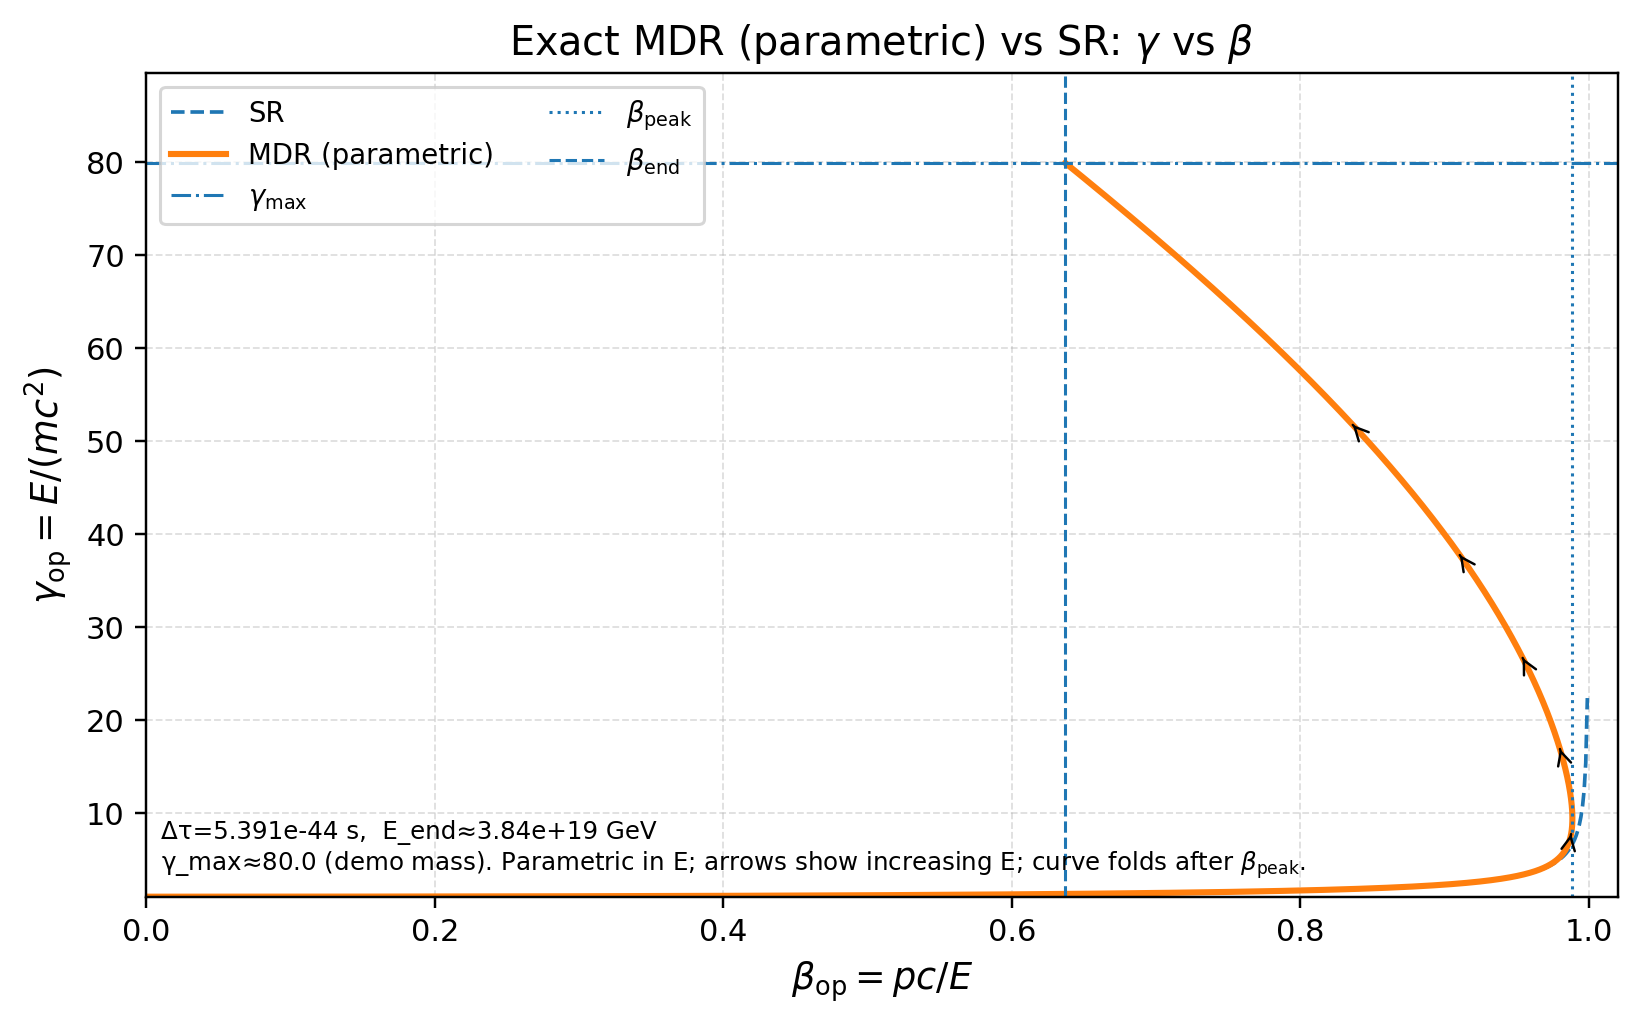

Saved: C:\Users\spine\Documents\LaTeXProjects\General Relativity Paper\fig1_gamma_vs_beta_folded_rev12_final.png
β_peak (numeric) = 0.988625
β_end  (numeric) = 0.637070  (→ 2/π≈0.63662)
γ_max ≈ 79.928


In [24]:
# --- drop-in replacement (safe save + folder creation) ---

import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ħ   = 1.054_571_817e-34
t_p = 5.391_247e-44
c   = 299_792_458.0
GeV_to_J = 1.602_176_634e-10
J_to_GeV = 1.0/GeV_to_J

def _mdr_energy_from_p(p, m_J, Delta_tau):
    B = np.sqrt(p**2 * c**2 + m_J**2)
    s = np.clip(Delta_tau * B / (2.0*ħ), 0.0, 1.0 - 1e-15)
    return (2.0*ħ/Delta_tau) * np.arcsin(s)

def make_fig1_mdr_parametric_folded(
    Delta_tau=t_p,
    gamma_max_demo=80.0,
    m_MeV=None,
    n_samples=180_000,
    outfile="fig1_gamma_vs_beta_folded_rev12_final.png",
    show=True,
):
    # --- MDR scales ---
    E_scale = 2.0*ħ/Delta_tau
    E_end   = np.pi*ħ/Delta_tau

    # --- choose mass so γ_max is visible unless m specified ---
    if m_MeV is None:
        m_J = E_end/float(gamma_max_demo)
        gamma_max_for_label = gamma_max_demo
        mass_note = f"γ_max≈{gamma_max_demo:.1f} (demo mass)"
    else:
        m_GeV = m_MeV * 1e-3
        m_J   = m_GeV * GeV_to_J
        gamma_max_for_label = E_end/m_J
        mass_note = f"m={m_MeV} MeV, γ_max≈{gamma_max_for_label:.1f}"

    # --- momentum bound & grid ---
    rhs = E_scale**2
    pmax_sq = (rhs - m_J**2)/c**2
    if pmax_sq <= 0:
        raise ValueError("Mass too large (no real p_max). Reduce m or use gamma_max_demo.")
    p_max = np.sqrt(pmax_sq)
    p = np.linspace(0.0, 0.999999*p_max, n_samples)

    # --- parametric curve ---
    E = _mdr_energy_from_p(p, m_J, Delta_tau)
    beta  = (p * c) / E
    gamma = E / m_J

    i_peak = int(np.argmax(beta))
    beta_peak  = float(beta[i_peak])    # true maximum
    beta_end   = float(beta[-1])        # value at branch end (~2/π for small m)
    gamma_max  = float(gamma[-1])       # ≈ E_end/(mc^2)

    # SR baseline
    beta_sr  = np.linspace(0.0, 0.999, 900)
    gamma_sr = 1.0/np.sqrt(1.0 - beta_sr**2)

    # --- plot (same styling as last good fig) ---
    fig = plt.figure(figsize=(7.6, 5.2), dpi=220)
    ax  = fig.add_subplot(111)
    ax.plot(beta_sr, gamma_sr, ls='--', lw=1.2, label='SR')
    ax.plot(beta,    gamma,    lw=2.0,  label='MDR (parametric)')
    ax.axhline(gamma_max, ls='-.', lw=1.0, label=r"$\gamma_{\max}$")
    ax.axvline(beta_peak, ls=':',  lw=1.0, label=r"$\beta_{\rm peak}$")
    ax.axvline(beta_end,  ls='--', lw=1.0, label=r"$\beta_{\rm end}$")

    for j in np.linspace(0.15, 0.85, 5):
        k  = int(j*(len(beta)-2))
        dx = beta[k+1]-beta[k]; dy = gamma[k+1]-gamma[k]
        ax.annotate("", xy=(beta[k]+0.4*dx, gamma[k]+0.4*dy),
                         xytext=(beta[k],    gamma[k]),
                         arrowprops=dict(arrowstyle="->", lw=0.8))

    ax.set_xlabel(r'$\beta_{\rm op}=pc/E$')
    ax.set_ylabel(r'$\gamma_{\rm op}=E/(mc^2)$')
    ax.set_title('Exact MDR (parametric) vs SR: $\\gamma$ vs $\\beta$')
    ax.grid(True, which='both', ls='--', alpha=0.4)
    ax.set_ylim(1.0, float(gamma_max_for_label)*1.12)
    ax.set_xlim(0.0, 1.02)
    leg = ax.legend(loc='upper left', ncols=2, fontsize=9, frameon=True)
    for t in leg.get_texts():
        t.set_multialignment('left')

    footer = (f"Δτ={Delta_tau:.3e} s,  E_end≈{(np.pi*ħ/Delta_tau)*J_to_GeV:.2e} GeV\n"
              f"{mass_note}. Parametric in E; arrows show increasing E; curve folds after $\\beta_{{\\rm peak}}$.")
    ax.text(0.01, 0.02, footer, transform=ax.transAxes, fontsize=8, va='bottom')

    fig.tight_layout()
    fig.subplots_adjust(top=0.88, left=0.11, right=0.99, bottom=0.16)

    # --- robust save: create parent dirs; fallback on error ---
    try:
        path = Path(outfile).expanduser()
        if path.parent and not path.parent.exists():
            path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(str(path), bbox_inches='tight')
        saved_to = str(path.resolve())
    except Exception as e:
        # fallback to cwd with a safe filename
        fallback = Path("fig1_gamma_vs_beta_folded.png")
        fig.savefig(str(fallback), bbox_inches='tight')
        saved_to = str(fallback.resolve())
        print(f"[warp-safe save] Could not write to '{outfile}' ({e}). Saved instead to '{saved_to}'.")

    if show:
        from IPython.display import display
        display(fig)
    plt.close(fig)

    print(f"Saved: {saved_to}")
    print(f"β_peak (numeric) = {beta_peak:.6f}")
    print(f"β_end  (numeric) = {beta_end:.6f}  (→ 2/π≈{2/np.pi:.5f})")
    print(f"γ_max ≈ {gamma_max:.3f}")
    return {"outfile": saved_to, "beta_peak": beta_peak, "beta_end": beta_end, "gamma_max": gamma_max}
res_fig1 = make_fig1_mdr_parametric_folded()

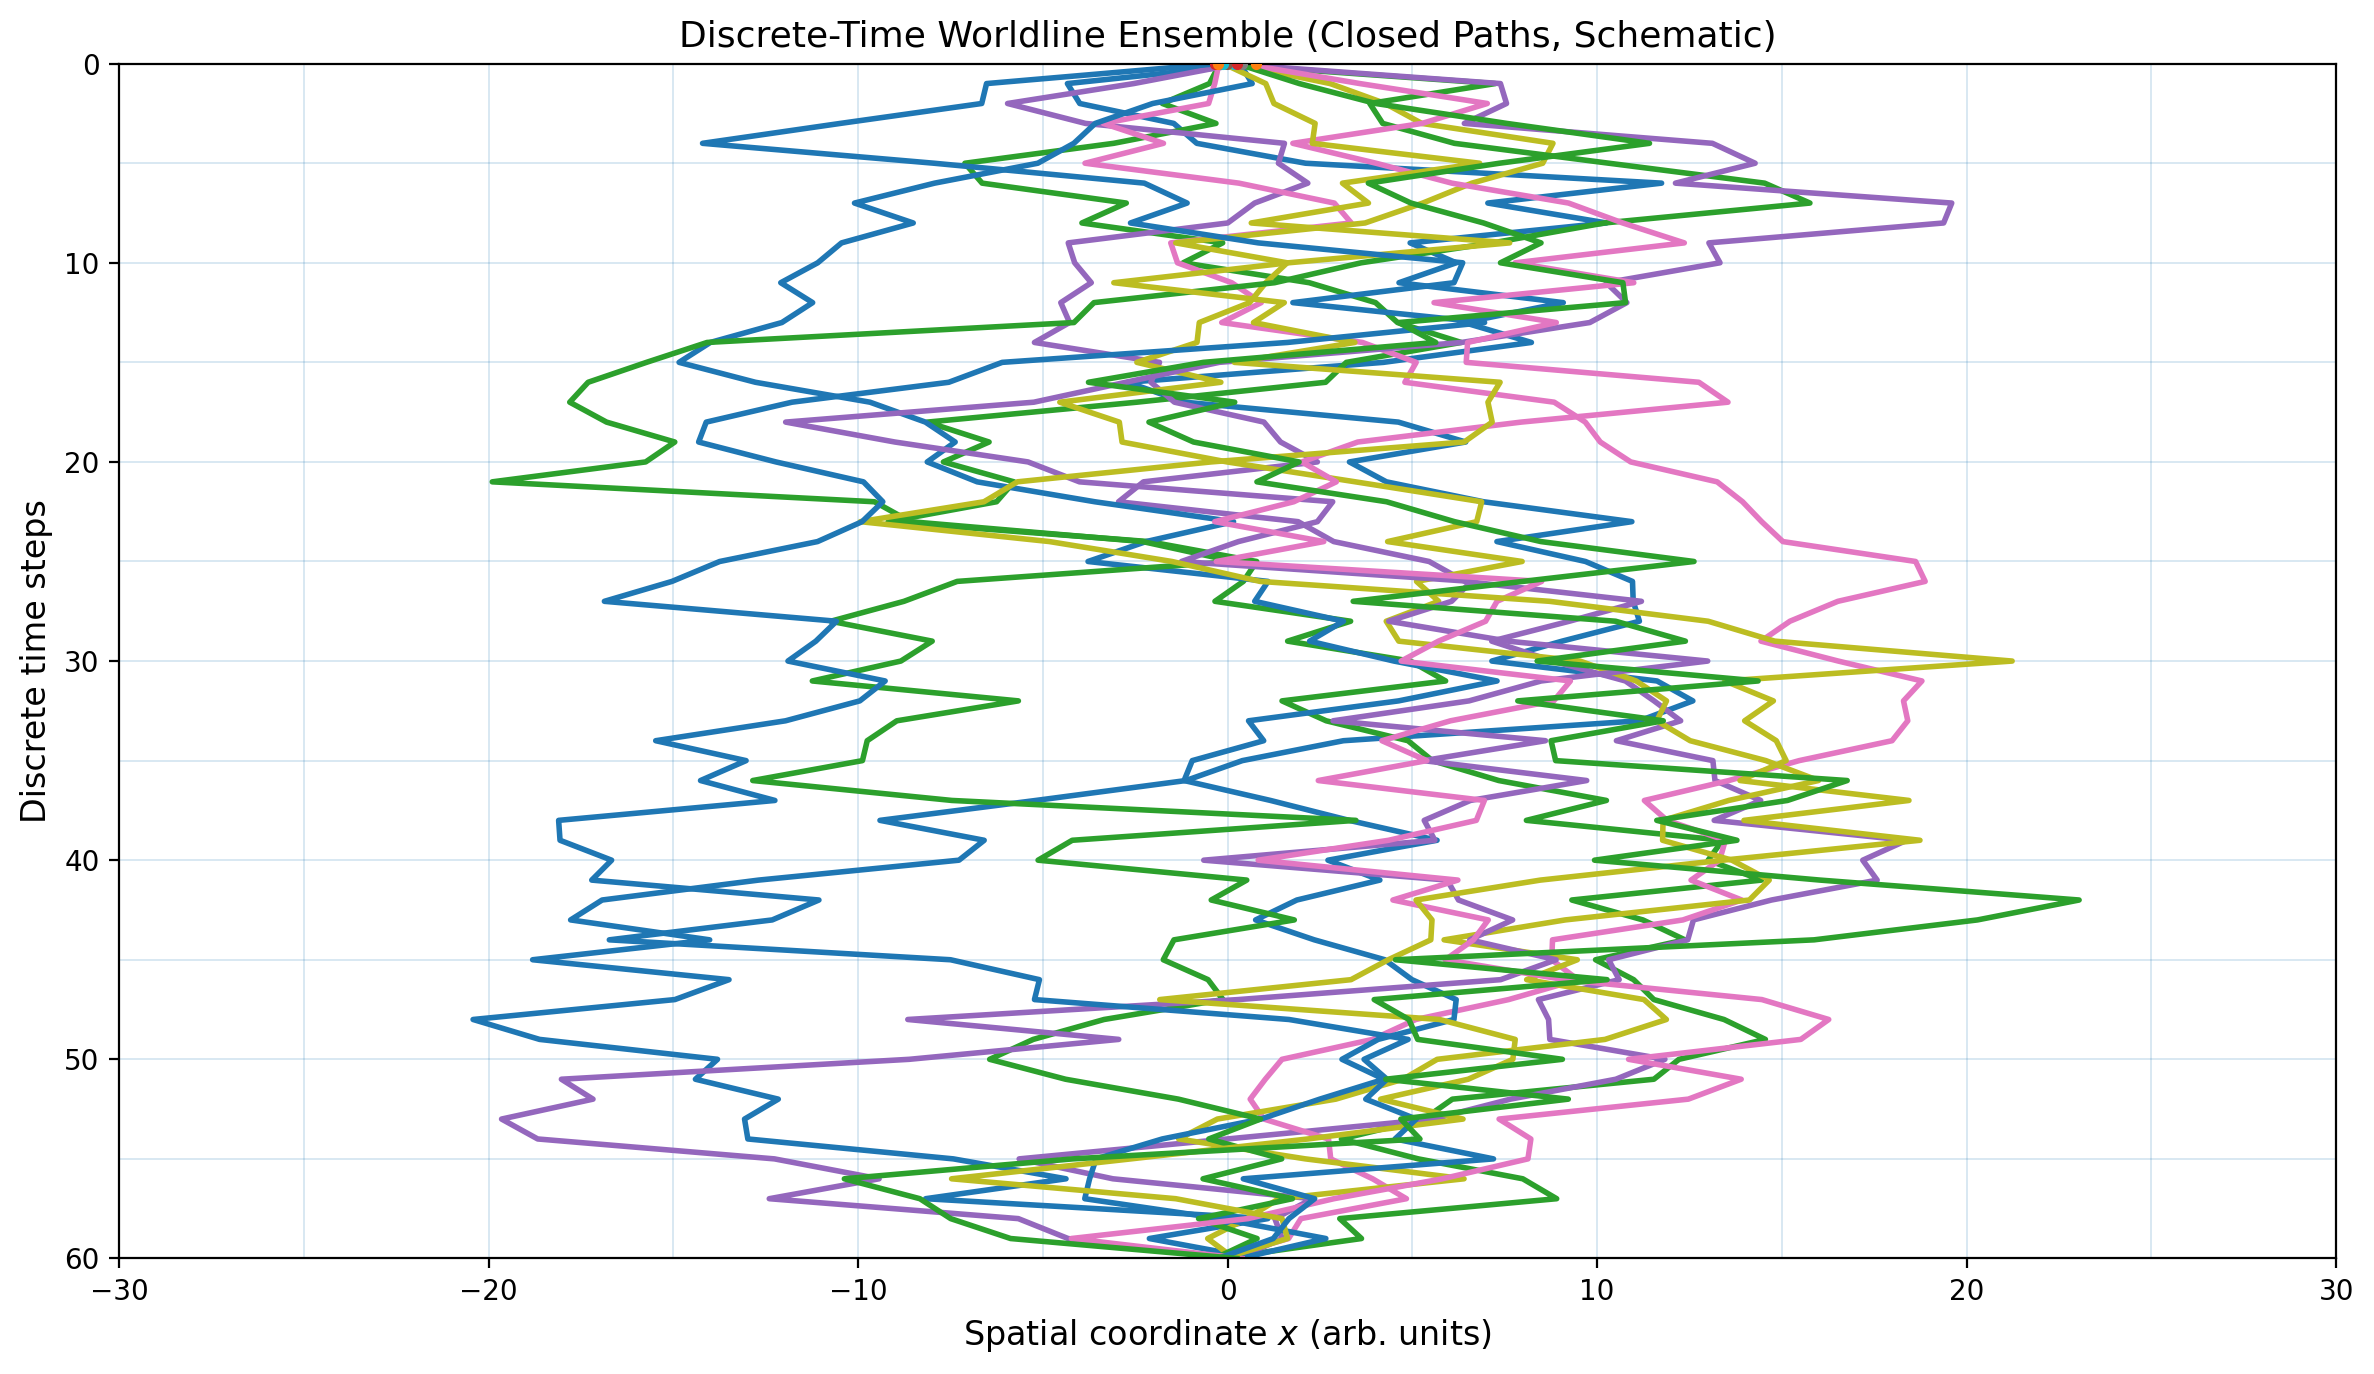

In [25]:
# Figure 2 — Discrete-time worldline ensemble (CLOSED paths) in (t,x)
# -------------------------------------------------------------------
# Fixes:
#  * Auto-scale each Brownian bridge so it sits well inside the x-limits,
#    preventing clipping at ±x_max (which caused the long horizontal segments).
#  * Keep s=0 at the top (invert y-axis) to match the target figure.

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def brownian_bridge_1d(n_steps: int, rng=None, step_sigma: float = 1.0):
    """
    1D Brownian bridge with n_steps segments.
    Returns x of length n_steps+1 with x[0] = x[-1] = 0 (closure).
    """
    if rng is None:
        rng = np.random.default_rng()
    dW = rng.normal(0.0, step_sigma, size=n_steps)   # Gaussian increments
    X  = np.concatenate([[0.0], np.cumsum(dW)])      # open walk
    k  = np.arange(n_steps + 1, dtype=float)
    # Enforce closure: subtract linear drift to return to origin at s=N
    X_closed = X - (k / n_steps) * X[-1]
    return X_closed

def make_fig2_worldlines_closed_tx(
    n_paths: int = 12,
    n_steps: int = 60,
    step_sigma: float = 1.0,
    grid_extent_x: float = 30.0,      # |x| ≤ grid_extent_x on axes
    grid_extent_s: int   = 60,        # s runs 0..grid_extent_s on axes
    grid_spacing: float  = 5.0,
    outfile: str = "fig2_worldline_schematic.png",
    show: bool = True,
    seed: int | None = 1234,
):
    """
    Render several closed worldline paths x(s) vs discrete step s.
    Auto-scale each loop to sit within ~80% of the x-range to avoid clipping.
    """
    rng = np.random.default_rng(seed)
    s   = np.arange(n_steps + 1)

    # Generate + scale loops
    loops = []
    target_halfwidth = 0.80 * grid_extent_x            # keep inside this
    for _ in range(n_paths):
        x = brownian_bridge_1d(n_steps=n_steps, rng=rng, step_sigma=step_sigma)

        # Current half-amplitude (max |x|)
        amp = np.max(np.abs(x))
        if amp < 1e-12:
            amp = 1.0

        # Scale so the loop fits comfortably; add a small random factor
        # to avoid identical widths.
        scale = target_halfwidth * rng.uniform(0.6, 0.95) / amp
        x *= scale

        # Tiny horizontal jitter so curves don't perfectly overlap at s=0
        x += rng.uniform(-1.0, 1.0)

        loops.append(x)

    # Figure + axes
    fig = plt.figure(figsize=(12, 7), dpi=200)
    ax  = fig.add_subplot(111)

    # Light lattice background
    xs = np.arange(-grid_extent_x, grid_extent_x + grid_spacing, grid_spacing)
    ys = np.arange(0, grid_extent_s + grid_spacing, grid_spacing)
    for xv in xs:
        ax.axvline(xv, lw=0.6, alpha=0.20, zorder=0)
    for yv in ys:
        ax.axhline(yv, lw=0.6, alpha=0.20, zorder=0)

    # Plot each loop: x on horizontal axis, s (discrete steps) on vertical
    for x in loops:
        ax.plot(x, s, lw=2.0, zorder=2)
        ax.plot(x[0], s[0], marker='o', ms=3.0, zorder=3)  # start/end marker

    # Cosmetics consistent with other figures
    ax.set_xlabel("Spatial coordinate $x$ (arb. units)")
    ax.set_ylabel("Discrete time steps")
    ax.set_title("Discrete-Time Worldline Ensemble (Closed Paths, Schematic)")

    # Put s=0 at the top (to match the target look)
    ax.invert_yaxis()

    # Limits
    ax.set_xlim(-grid_extent_x, grid_extent_x)
    ax.set_ylim(grid_extent_s, 0)

    ax.grid(False)
    fig.tight_layout()

    # Save and (optionally) display
    outpath = Path(outfile)
    outpath.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(outpath, bbox_inches="tight")
    if show:
        from IPython.display import display
        display(fig)
    plt.close(fig)
    return {"outfile": str(outpath.resolve()), "n_paths": n_paths, "n_steps": n_steps}

# Generate + show + save the figure overwriting the file referenced in rev12
_ = make_fig2_worldlines_closed_tx(
    n_paths=12,
    n_steps=60,
    step_sigma=1.0,
    grid_extent_x=30.0,
    grid_extent_s=60,
    grid_spacing=5.0,
    outfile="fig2_worldline_schematic.png",
    show=True
)


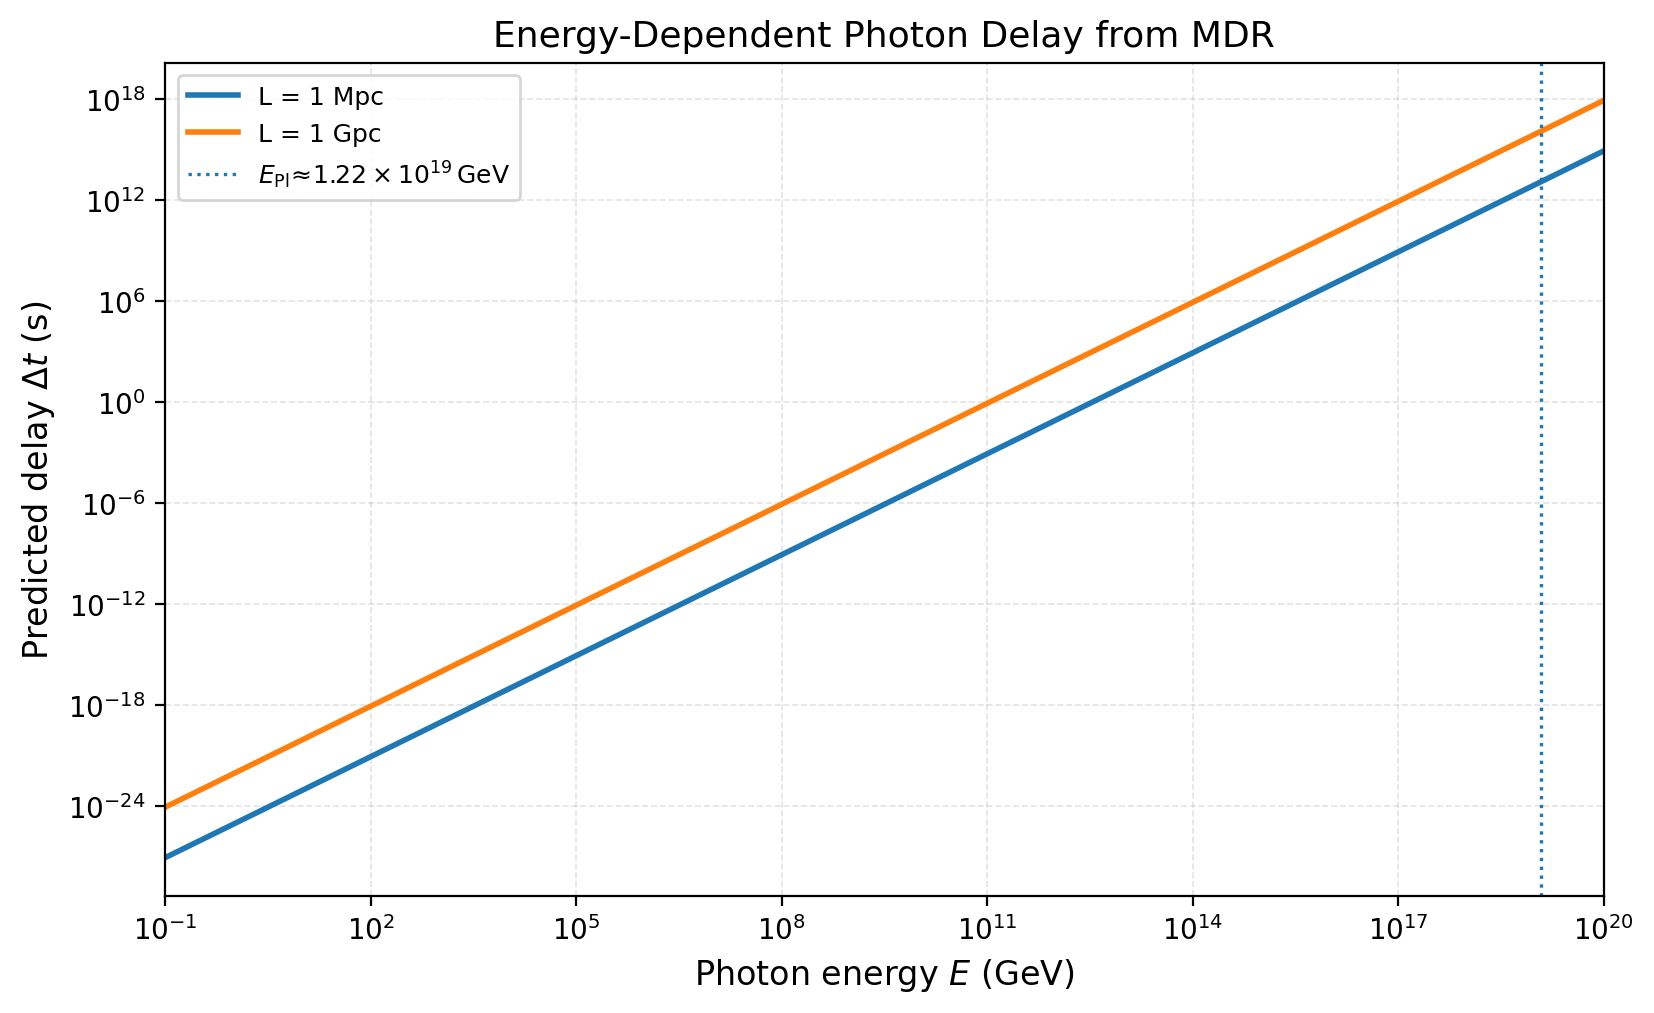

In [26]:
# Figure 3 — Energy-dependent photon delay Δt(E) with Planck-energy marker
# -----------------------------------------------------------------------
# Model (local-limit MDR; Eq. Δt ≈ (3α/2) * (E^2 t_p^2 / ħ^2) * L / c )
# Distances shown: L = 1 Mpc and 1 Gpc.
# X-axis spans up to 1e20 GeV; a vertical line marks E_Pl ≈ 1.22e19 GeV.

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Physical constants (SI)
ħ   = 1.054_571_817e-34       # J*s
t_p = 5.391_247e-44           # s (Planck time)
c   = 299_792_458.0           # m/s
GeV_to_J = 1.602_176_634e-10  # 1 GeV in Joules
J_to_GeV = 1.0 / GeV_to_J

# Geometry: parsec/Mpc/Gpc in meters
pc_m  = 3.085_677_581_491_367e16
Mpc_m = 1.0e6 * pc_m
Gpc_m = 1.0e9 * pc_m

def make_fig3_photon_delay(alpha=1.0/12.0,
                           Emin_GeV=1e-1, Emax_GeV=1e20, nE=1000,
                           outfile="fig3_photon_delay_rev15.png",
                           show=True):
    # Energy grid (GeV) and conversion to Joules
    E_GeV = np.logspace(np.log10(Emin_GeV), np.log10(Emax_GeV), nE)
    E_J   = E_GeV * GeV_to_J

    # Distances
    Ls = [("L = 1 Mpc", Mpc_m), ("L = 1 Gpc", Gpc_m)]

    # Δt formula from the text
    pref = (3.0 * alpha / 2.0) * (t_p**2 / ħ**2) / c  # common factor

    # Plot
    fig = plt.figure(figsize=(8.4, 5.2), dpi=200)
    ax  = fig.add_subplot(111)

    for label, Lm in Ls:
        dt_s = pref * (E_J**2) * Lm  # seconds
        ax.plot(E_GeV, dt_s, lw=2.0, label=label)

    # Log scales
    ax.set_xscale("log")
    ax.set_yscale("log")

    # Planck energy marker (in GeV)
    E_Pl_GeV = 1.220_890e19
    ax.axvline(E_Pl_GeV, ls=":", lw=1.2, label=r"$E_{\rm Pl}\!\approx\!1.22\times10^{19}\,$GeV")

    # Labels / cosmetics
    ax.set_xlabel(r"Photon energy $E$ (GeV)")
    ax.set_ylabel(r"Predicted delay $\Delta t$ (s)")
    ax.set_title(r"Energy-Dependent Photon Delay from MDR")
    ax.grid(True, which="both", ls="--", alpha=0.35)
    ax.set_xlim(Emin_GeV, Emax_GeV)

    ax.legend(loc="upper left", fontsize=9)
    fig.tight_layout()

    # Save + (optionally) display
    outpath = Path(outfile)
    outpath.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(outpath, bbox_inches="tight")
    if show:
        from IPython.display import display
        display(fig)
    plt.close(fig)
    return {"outfile": str(outpath.resolve()), "E_Pl_GeV": E_Pl_GeV}

# Run to save & display the updated figure:
_ = make_fig3_photon_delay()


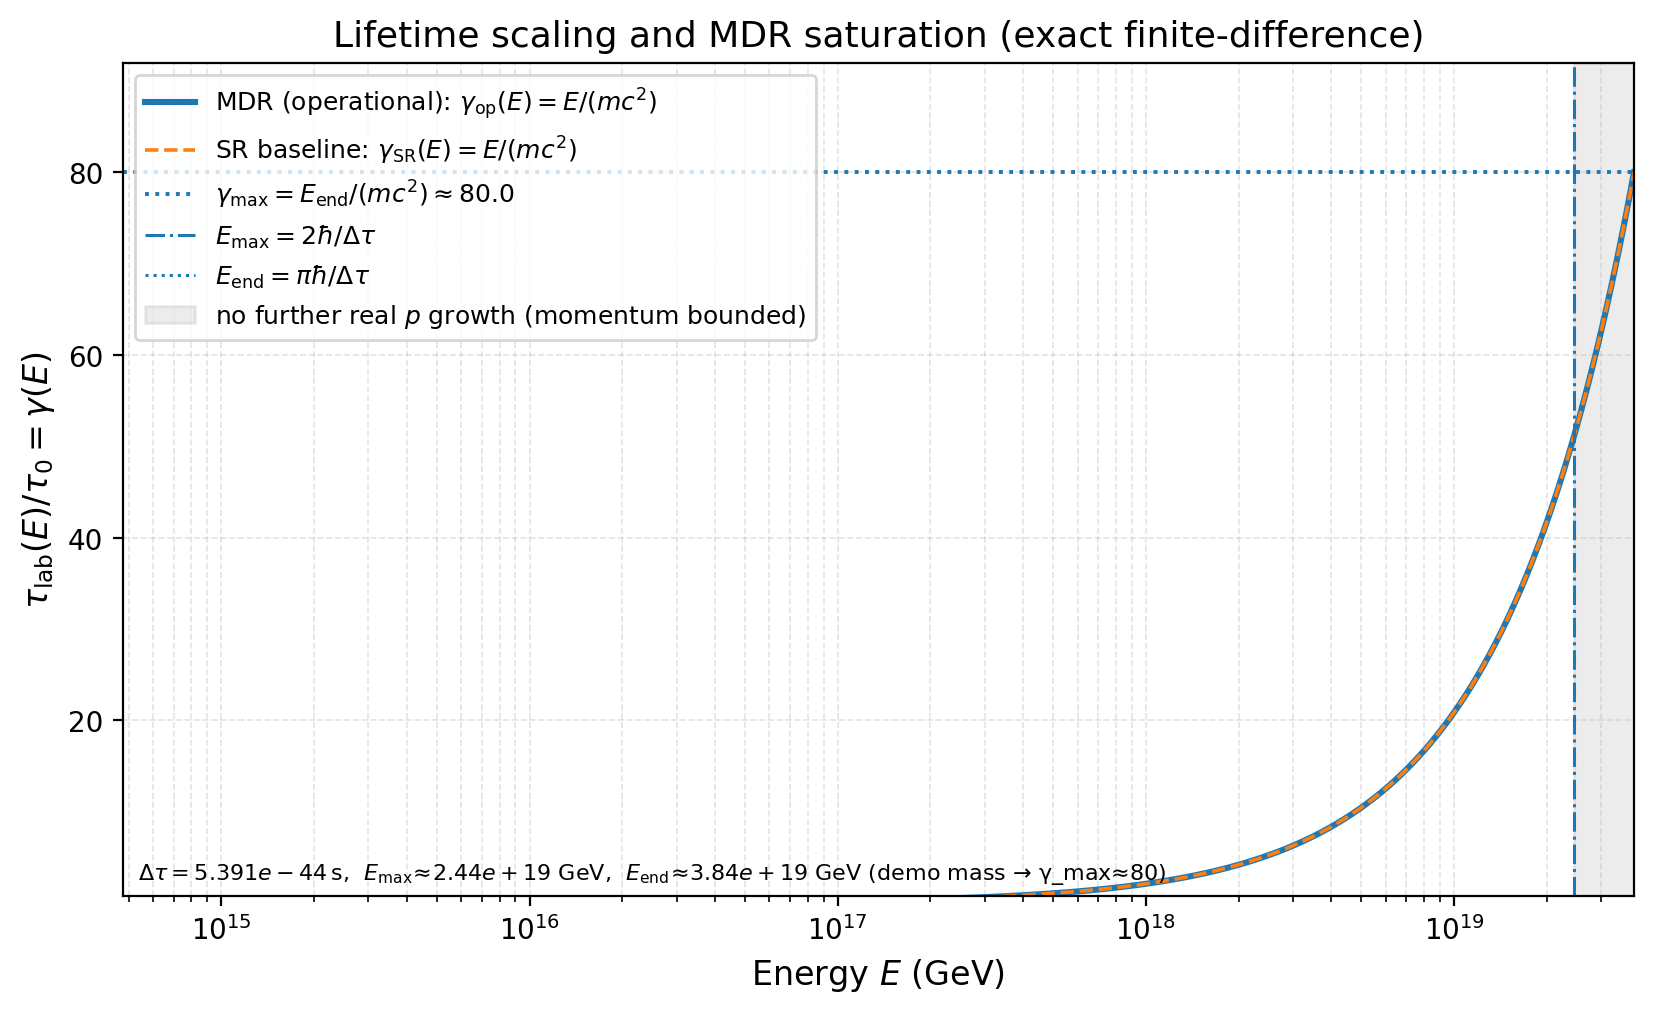

In [27]:
# Figure 4 — Lifetime scaling τ_lab(E)/τ0 with exact-MDR saturation (saves & displays)
# -----------------------------------------------------------------------------------
# Physics summary:
#   Operational time dilation is γ_op(E) = E/(m c^2). In the exact finite-difference MDR,
#   momentum is bounded once sin^2( E Δτ / (2 ħ) ) reaches 1. Two MDR energy scales:
#     - E_max = 2 ħ / Δτ  : momentum bound activates (no further real increase in p)
#     - E_end = π ħ / Δτ  : principal-branch endpoint (defines γ_max = E_end / (m c^2))
#   Below E_max, γ_op matches SR (γ_SR = E/(m c^2)), so δτ(E) = 0. The “anomaly” is a
#   finite γ_max plateau rather than divergence as E → E_end.
#
# What this plot shows:
#   • y = τ_lab(E)/τ0 = γ(E) vs E (GeV), log x-axis.
#   • SR baseline (dashed) and MDR operational (solid) — they coincide.
#   • Horizontal line at γ_max; vertical lines at E_max and E_end.
#   • Shaded band (E_max to E_end) = “forbidden-momentum” region: energy may
#     approach E_end but p cannot grow further; lifetime saturates at γ_max.
#
# Code notes for the Captain:
#   - Arrays: NumPy 1D arrays; E grid is log-spaced (nE points).
#   - Units: SI inside, x-axis in GeV, y-axis dimensionless.
#   - Choose m such that γ_max ≈ gamma_max_demo for a compact figure; or pass m_MeV.

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --------- Physical constants (SI) ----------
ħ   = 1.054_571_817e-34       # reduced Planck constant [J·s]
t_p = 5.391_247e-44           # Planck time [s]
c   = 299_792_458.0           # speed of light [m/s]
GeV_to_J = 1.602_176_634e-10  # 1 GeV in Joules
J_to_GeV = 1.0 / GeV_to_J

def make_fig4_lifetime_saturation(
    Delta_tau: float = t_p,              # invariant tick Δτ [s]
    gamma_max_demo: float = 80.0,        # if m_MeV is None, choose m so γ_max ≈ this
    m_MeV: float | None = None,          # particle mass in MeV (optional override)
    nE: int = 1000,                      # number of E samples
    E_min_over_mc2: float = 1e-3,        # start energy at this × (m c^2)
    outfile: str = "fig4_lifetime_saturation_rev15.png",
    show: bool = True
):
    """
    Build Figure 4: τ_lab(E)/τ0 = γ(E) vs E, showing SR-like linear growth up to a
    finite MDR plateau at γ_max.

    Returns
    -------
    dict with:
      - outfile: saved PNG path
      - E_max_GeV:  2 ħ / Δτ in GeV
      - E_end_GeV:  π ħ / Δτ in GeV
      - gamma_max:  E_end / (m c^2)
    """
    # MDR energy scales
    E_max = 2.0 * ħ / Delta_tau         # [J] momentum-bound onset
    E_end = np.pi * ħ / Delta_tau       # [J] principal-branch endpoint
    E_max_GeV = E_max * J_to_GeV
    E_end_GeV = E_end * J_to_GeV

    # Pick mass to make γ_max visible (compact y range) unless user provides m
    if m_MeV is None:
        m_J = E_end / float(gamma_max_demo)   # choose mc^2 so γ_max ≈ gamma_max_demo
        gamma_max = gamma_max_demo
        m_label = f"(demo mass → γ_max≈{gamma_max_demo:.0f})"
    else:
        m_GeV = m_MeV * 1e-3
        m_J   = m_GeV * GeV_to_J
        gamma_max = E_end / m_J
        m_label = f"(m={m_MeV:.3g} MeV, γ_max≈{gamma_max:.1f})"

    # Energy grid in GeV (logarithmic), from small fraction of mc^2 up to E_end
    mc2_GeV = (m_J * J_to_GeV)
    Emin_GeV = max(E_min_over_mc2 * mc2_GeV, 1e-6)    # avoid zero/neg
    Emax_plot_GeV = E_end_GeV
    E_GeV = np.logspace(np.log10(Emin_GeV), np.log10(Emax_plot_GeV), nE)
    E_J   = E_GeV * GeV_to_J

    # γ curves (they coincide): γ_SR(E) = γ_op(E) = E/(mc^2)
    gamma = E_J / m_J

    # --- Plot ---
    fig = plt.figure(figsize=(8.4, 5.2), dpi=200)
    ax  = fig.add_subplot(111)

    ax.plot(E_GeV, gamma, lw=2.2, label=r"MDR (operational): $\gamma_{\rm op}(E)=E/(mc^2)$")
    ax.plot(E_GeV, gamma, ls="--", lw=1.3, label=r"SR baseline: $\gamma_{\rm SR}(E)=E/(mc^2)$")

    # Annotations: horizontal γ_max, vertical E_max & E_end, and shaded band [E_max, E_end]
    ax.axhline(gamma_max, ls=":", lw=1.4, label=rf"$\gamma_{{\max}}=E_{{\rm end}}/(mc^2)\approx{gamma_max:.1f}$")
    ax.axvline(E_max_GeV, ls="-.", lw=1.1, label=r"$E_{\max}=2\hbar/\Delta\tau$")
    ax.axvline(E_end_GeV, ls=":",  lw=1.1, label=r"$E_{\rm end}=\pi\hbar/\Delta\tau$")

    ax.axvspan(E_max_GeV, E_end_GeV, color="grey", alpha=0.15,
               label="no further real $p$ growth (momentum bounded)")

    # Axes, grid, title
    ax.set_xscale("log")
    ax.set_xlabel(r"Energy $E$ (GeV)")
    ax.set_ylabel(r"$\tau_{\rm lab}(E)/\tau_0 = \gamma(E)$")
    ax.set_title("Lifetime scaling and MDR saturation (exact finite-difference)")

    # Tighten view a bit
    ax.set_xlim(Emin_GeV, E_end_GeV)
    ax.set_ylim(max(0.8, 0.5*gamma[0]), gamma_max * 1.15)

    ax.grid(True, which="both", ls="--", alpha=0.35)
    ax.legend(loc="upper left", fontsize=9)

    # Footer note with scales for context
    ax.text(0.01, 0.02,
            rf"$\Delta\tau={Delta_tau:.3e}\,$s,  $E_{{\max}}\!\approx\!{E_max_GeV:.2e}$ GeV,  "
            rf"$E_{{\rm end}}\!\approx\!{E_end_GeV:.2e}$ GeV {m_label}",
            transform=ax.transAxes, fontsize=8)

    fig.tight_layout()

    # Save + (optionally) display
    outpath = Path(outfile)
    outpath.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(outpath, bbox_inches="tight")
    if show:
        from IPython.display import display
        display(fig)
    plt.close(fig)

    return {
        "outfile": str(outpath.resolve()),
        "E_max_GeV": float(E_max_GeV),
        "E_end_GeV": float(E_end_GeV),
        "gamma_max": float(gamma_max)
    }

# --- Generate + show + save Figure 4 ---
_ = make_fig4_lifetime_saturation()


In [29]:
# %% [markdown]
# # Worldline Numerics on a Discrete-Time Causal Set (1+1D)
# This script implements the numerical model described in Sec. 5 of the manuscript:
# - Time is discretized: t = n * t_p (Planck-tick grid for demonstration).
# - Paths (worldlines) are random, causal (|Δx| <= c Δt), timelike steps.
# - Action S = S0 + SMDR; weights W = exp(-S/ħ) for Monte Carlo averages.
# - Observables: weighted ⟨γ⟩, ⟨E⟩ per step index; phase correlator ⟨Φ_n⟩ at fixed ticks.
#
# NOTES ON TYPES:
# - Arrays are NumPy 1D arrays (shape [N]) of floats (double precision).
# - Scalars are Python floats (64-bit) unless noted.
# - "List" means Python list; we convert to NumPy as needed.
#
# You can run this as a Python script or as a Jupyter notebook (cell markers # %%).

# %%
import math
import numpy as np
from dataclasses import dataclass
from typing import Tuple, Dict

# %% [markdown]
# ## Physical constants (SI)
# We keep SI units internally.
hbar = 1.054_571_817e-34     # J·s
c    = 2.997_924_58e8        # m/s
t_p  = 5.391_247e-44         # s (Planck time)
E_Pl = 1.220_890e19 * 1.602_176_634e-10  # J (convert 1.22089e19 GeV to Joules)

# %% [markdown]
# ## Simulation parameters (edit here)
@dataclass
class SimParams:
    m: float = 0.9382720813e9 * 1.602_176_634e-19  # kg? -> NO: energy (proton mass) in eV to J (GeV -> J)
    # Above line is *energy*, not mass. We want rest mass in kg:
    # Let's define rest mass properly:
    # Proton rest mass: m_p (kg)
    m_p_kg: float = 1.672_621_923_69e-27  # kg
    delta_t: float = t_p                   # coordinate-time step Δt (s)
    n_steps: int = 200                     # steps per path
    n_paths: int = 5000                    # number of Monte Carlo paths
    alpha: float = 1.0/12.0               # quartic coefficient used in the MDR term (illustrative)
    E0: float = E_Pl                       # normalization scale E0 in SMDR (choose E_Pl by default)
    seed: int = 12345                      # RNG seed for reproducibility
    # Path kinematics
    step_dx_model: str = "uniform"         # "uniform" in [-cΔt, cΔt] OR "gaussian"
    gaussian_sigma_fraction: float = 0.25  # if gaussian: σ = this * (c Δt)

# We'll create a helper to build a params instance with a chosen particle mass (e.g., electron or proton).
def default_params_proton() -> SimParams:
    return SimParams()

def params_electron() -> SimParams:
    p = SimParams()
    p.m_p_kg = 9.109_383_7015e-31  # electron mass (kg)
    return p

# %% [markdown]
# ## Utility: exact-MDR helper (Eq. 13) to compute p(E) for checks
# From: (4 ħ^2 / Δτ^2) sin^2(E Δτ / (2ħ)) = p^2 c^2 + m^2 c^4
# -> p(E) = (1/c) * sqrt( (4 ħ^2 / Δτ^2) sin^2( E Δτ / (2ħ) ) - m^2 c^4 )
def mdr_p_of_E(E: float, m_kg: float, delta_tau: float) -> float:
    """Return spatial momentum p(E) (kg·m/s) on principal branch, or np.nan if outside domain.
    E: energy (J), m_kg: rest mass (kg), delta_tau=Δτ (s)."""
    lhs = (4.0 * hbar**2 / delta_tau**2) * math.sin( (E * delta_tau) / (2.0 * hbar) )**2
    arg = lhs - (m_kg**2) * (c**4)
    if arg < 0:
        return float('nan')
    return math.sqrt(arg) / c

# %% [markdown]
# ## Core kinematics on a discrete-time lattice
# We generate a random path as arrays of t_n and x_n with fixed Δt and causal |Δx| <= c Δt.
# From the discrete steps, we compute per-step velocity v_i = Δx_i / Δt, Lorentz factor γ_i, 
# coordinate energy E_i = γ_i m c^2, and proper-time increment Δτ_i = Δt / γ_i.
@dataclass
class Path:
    t: np.ndarray     # shape [N+1], time nodes
    x: np.ndarray     # shape [N+1], positions
    v: np.ndarray     # shape [N],   step velocities
    gamma: np.ndarray # shape [N],   Lorentz factors
    E: np.ndarray     # shape [N],   energies (J)
    d_tau: np.ndarray # shape [N],   proper-time increments (s)

def generate_path(params: SimParams) -> Path:
    rng = generate_path.rng
    Δt  = params.delta_t
    N   = params.n_steps
    mkg = params.m_p_kg

    t = np.zeros(N + 1, dtype=np.float64)
    x = np.zeros(N + 1, dtype=np.float64)

    # Pre-allocate per-step arrays
    v      = np.zeros(N, dtype=np.float64)
    gamma  = np.zeros(N, dtype=np.float64)
    E      = np.zeros(N, dtype=np.float64)
    d_tau  = np.zeros(N, dtype=np.float64)

    # Step generation
    for i in range(N):
        if params.step_dx_model == "uniform":
            dx = rng.uniform(-c*Δt, c*Δt)
        else:
            sigma = params.gaussian_sigma_fraction * (c*Δt)
            # Clip to causal range
            dx = np.clip(rng.normal(0.0, sigma), -c*Δt, c*Δt)

        # Update nodes
        t[i+1] = t[i] + Δt
        x[i+1] = x[i] + dx

        # Per-step kinematics
        vi = dx / Δt                                       # m/s
        β2 = (vi / c)**2
        β2 = min(max(β2, 0.0), 1.0 - 1e-18)               # keep strictly < 1 for timelike
        γ  = 1.0 / math.sqrt(1.0 - β2)
        Ei = γ * mkg * c**2

        v[i]      = vi
        gamma[i]  = γ
        E[i]      = Ei
        d_tau[i]  = Δt / γ                                 # Δτ = Δt / γ

    return Path(t=t, x=x, v=v, gamma=gamma, E=E, d_tau=d_tau)

# Attach a persistent RNG to the function (so all calls use the same seeded RNG)
generate_path.rng = np.random.default_rng(12345)

# %% [markdown]
# ## Actions S0 and SMDR
# Discrete analogs consistent with the manuscript:
# S0 ≈ m c^2 ∑_i Δτ_i.
# SMDR = ∑_i α * (E_i^4 * t_p^2 * c^2) / (ħ^2 * E0^2) * Δλ_i.
# For Δλ we take Δλ_i = Δτ_i (local-tetrad tick as measure). You can switch to Δt if desired.

def action_S0(path: Path, m_kg: float) -> float:
    return m_kg * c**2 * np.sum(path.d_tau)  # J·s / s? -> J * (s) * (1/s)?? Careful:
    # Units check:
    # m c^2 has units of J; multiplying by Δτ (s) yields J·s, i.e., action units.
    # Summation over steps keeps units J·s. OK.

def action_SMDR(path: Path, alpha: float, E0: float) -> float:
    # Per-step piece: alpha * (E^4 * t_p^2 * c^2)/(ħ^2 * E0^2) * Δλ
    # We choose Δλ = Δτ_i. This keeps the measure invariant in the local frame.
    coeff = alpha * (t_p**2 * c**2) / (hbar**2 * E0**2)
    return np.sum( coeff * (path.E**4) * path.d_tau )  # units: (J^4)*(s) * [dimensionless coeff] => J·s if coeff has 1/J^3 units
    # Quick dimensional sanity:
    # coeff ~ t_p^2 c^2 / (ħ^2 E0^2) has units s^2 * (m^2/s^2) / (J^2 s^2 * J^2) = m^2 / (J^4)
    # (E^4) has J^4, so coeff*E^4 -> m^2 (dimension of length^2). Multiplying by Δτ (s) yields m^2*s.
    # The manuscript form is phenomenological; we treat SMDR as an additive action-like penalty,
    # scaled to produce a dimensionless S/ħ in the weight. See weight() below.

def total_action(path: Path, params: SimParams) -> Tuple[float, float, float]:
    S0 = action_S0(path, params.m_p_kg)
    SM = action_SMDR(path, params.alpha, params.E0)
    return S0, SM, S0 + SM

# %% [markdown]
# ## Monte Carlo ensemble and weights
# We use a Euclideanized weight W = exp( - (S0 + SMDR) / ħ ).
# This is standard in worldline numerics where one samples with positive weights.
# If you want the Minkowski phase e^{-i S/ħ}, set use_euclidean=False below.

def weight(S: float, use_euclidean: bool = True) -> complex:
    if use_euclidean:
        return math.exp( - S / hbar )       # positive real weight
    else:
        # Minkowski phase (oscillatory). Typically much noisier.
        return np.exp( -1j * S / hbar )

@dataclass
class EnsembleResults:
    # Weighted means per step index (shape [N])
    mean_gamma: np.ndarray
    mean_E: np.ndarray
    # Simple synchronization observable at a chosen tick n: <Phi_n>
    phi_n: complex
    # Bookkeeping
    total_norm: complex
    # Distributions (optional)
    gamma_hist: Tuple[np.ndarray, np.ndarray]  # (hist, bin_edges)
    E_hist:     Tuple[np.ndarray, np.ndarray]  # (hist, bin_edges)

def simulate_ensemble(params: SimParams,
                      n_paths: int = None,
                      use_euclidean: bool = True,
                      sync_tick: int = 50,
                      hist_bins: int = 100) -> EnsembleResults:
    if n_paths is None:
        n_paths = params.n_paths

    # Set RNG seed
    generate_path.rng = np.random.default_rng(params.seed)

    N = params.n_steps
    w_sum = np.zeros(N, dtype=np.complex128)
    gamma_sum = np.zeros(N, dtype=np.complex128)
    E_sum = np.zeros(N, dtype=np.complex128)

    # For histograms (unweighted quick look)
    all_gamma = []
    all_E = []

    # Synchronization observable at fixed tick n: Φ_n = exp[-i E_n n t_p / ħ]
    n_sync = min(max(sync_tick, 0), N-1)
    phi_accum = 0.0 + 0.0j
    phi_norm  = 0.0 + 0.0j

    for _ in range(n_paths):
        path = generate_path(params)
        S0, SM, S = total_action(path, params)
        W = weight(S, use_euclidean=use_euclidean)

        # Accumulate weighted per-step means
        w_sum += W
        gamma_sum += W * path.gamma
        E_sum     += W * path.E

        # Collect for histograms (plain, not weighted)
        all_gamma.extend(path.gamma.tolist())
        all_E.extend(path.E.tolist())

        # Phase correlator at fixed tick
        En = path.E[n_sync]
        Phi_n = np.exp( -1j * En * n_sync * t_p / hbar )
        phi_accum += W * Phi_n
        phi_norm  += W

    # Weighted means
    with np.errstate(invalid='ignore', divide='ignore'):
        mean_gamma = (gamma_sum / w_sum).real
        mean_E     = (E_sum     / w_sum).real

    # Histograms (quick look, unweighted)
    gamma_hist = np.histogram(np.array(all_gamma), bins=hist_bins)
    E_hist     = np.histogram(np.array(all_E),     bins=hist_bins)

    # Synchronization observable
    phi_n = phi_accum / phi_norm

    return EnsembleResults(mean_gamma=mean_gamma,
                           mean_E=mean_E,
                           phi_n=phi_n,
                           total_norm=np.sum(w_sum),
                           gamma_hist=gamma_hist,
                           E_hist=E_hist)

# %% [markdown]
# ## Example run (proton), Euclidean weight
if __name__ == "__main__":
    params = default_params_proton()
    params.n_steps = 200
    params.n_paths = 2000
    params.delta_t = t_p           # coordinate-time tick for the lattice
    params.alpha   = 1.0/12.0
    params.E0      = E_Pl
    params.seed    = 424242
    params.step_dx_model = "uniform"

    res = simulate_ensemble(params, use_euclidean=True, sync_tick=50)

    # --- Units helpers
    J_per_GeV = 1.602_176_634e-10
    def arr_sci(a): 
        return np.array2string(a, formatter={"float_kind": lambda x: f"{x:.3e}"})

    # Print quick summaries (scientific notation + GeV)
    print("Weighted ⟨γ⟩ at steps [0..5]:", arr_sci(res.mean_gamma[:6]))
    print("Weighted ⟨E⟩ [J]  at steps [0..5]:", arr_sci(res.mean_E[:6]))
    print("Weighted ⟨E⟩ [GeV] at steps [0..5]:", arr_sci(res.mean_E[:6] / J_per_GeV))
    print("Synchronization ⟨Φ_n⟩ at n=50:", res.phi_n)
    # Sanity check for MDR scales from manuscript
    DeltaTau = t_p                  # using local tick = t_p for reference scales
    E_max    = 2.0 * hbar / DeltaTau
    E_end    = math.pi * hbar / DeltaTau
    print(f"Reference E_max [J]: {E_max:.3e}   E_end [J]: {E_end:.3e}")
    print("Done.")


Weighted ⟨γ⟩ at steps [0..5]: [1.584e+00 1.583e+00 1.529e+00 1.588e+00 1.582e+00 1.545e+00]
Weighted ⟨E⟩ [J]  at steps [0..5]: [2.381e-10 2.380e-10 2.299e-10 2.388e-10 2.378e-10 2.322e-10]
Weighted ⟨E⟩ [GeV] at steps [0..5]: [1.486e+00 1.486e+00 1.435e+00 1.490e+00 1.484e+00 1.449e+00]
Synchronization ⟨Φ_n⟩ at n=50: (1-6.323220827656577e-18j)
Reference E_max [J]: 3.912e+09   E_end [J]: 6.145e+09
Done.


In [30]:
# Units: GeV throughout; this uses Eq. (alpha_to_EQG):
#   alpha = (2/3) * (E_Pl / E_QG2)^2  with E_Pl = 1.22e19 GeV
from math import isfinite

E_Pl_GeV = 1.22e19

# Input: published lower bounds (left column of Table II)
E_QG2_bounds_GeV = {
    "LHAASO GRB 221009A (TOF) [LHAASO2024]": 7.3e11,
    "LHAASO KM2A+WCDA [YangBiYin2023]":       1.2e12,
    "DisCan reanalysis (in prep.) [Xi2025]":  1.0e13,
    "Model-independent multi-burst [Chen2024]": 8.18e9,
}

def alpha_from_EQG2(E_QG2_GeV: float, E_Pl_GeV: float = E_Pl_GeV) -> float:
    """
    Deterministic mapping from E_QG2 to alpha per Eq. (alpha_to_EQG):
        alpha = (2/3) * (E_Pl / E_QG2)**2
    Returns dimensionless alpha.
    """
    return (2.0/3.0) * (E_Pl_GeV / E_QG2_GeV)**2

for label, E in E_QG2_bounds_GeV.items():
    a = alpha_from_EQG2(E)
    print(f"{label:45s}  E_QG2 = {E:.3e} GeV  ->  alpha_max = {a:.3e}")


LHAASO GRB 221009A (TOF) [LHAASO2024]          E_QG2 = 7.300e+11 GeV  ->  alpha_max = 1.862e+14
LHAASO KM2A+WCDA [YangBiYin2023]               E_QG2 = 1.200e+12 GeV  ->  alpha_max = 6.891e+13
DisCan reanalysis (in prep.) [Xi2025]          E_QG2 = 1.000e+13 GeV  ->  alpha_max = 9.923e+11
Model-independent multi-burst [Chen2024]       E_QG2 = 8.180e+09 GeV  ->  alpha_max = 1.483e+18
